# Task predittivo 

L'obbiettivo posto in questo notebook è quello di andare ad utilizzare un modell di machine learning in particolare il Random Forest per fare predizione sull'abbandono dei clienti bancari. Il nostro compito sarà quello di riuscire a predire e quindi prevedere l'abbandono di un cliente.

In [8]:
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd

def grid_ottimiz(
    X, y,
    model1, param_grid1, name1,
    cv_split,
    score,
    jobs=-1
):
    """
    Esegue una GridSearchCV su due modelli con confronto finale.

    Parametri:
    - X, y: dati e target (np.array o pd.DataFrame/Series)
    - model1, model2: modelli o pipeline sklearn
    - param_grid1, param_grid2: dizionario parametri per ciascun modello
    - name1, name2: stringhe descrittive dei modelli
    - cv_split: oggetto CV (es. KFold, StratifiedKFold)
    - score: metrica (es. 'accuracy')
    - jobs: numero di job paralleli (-1 = tutti)
    """

    def fit_and_report(model, param_grid, model_name):
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=cv_split,
            scoring=score,
            n_jobs=jobs
        )
        grid.fit(X, y)

        results = grid.cv_results_
        best_params = grid.best_params_
        best_score = grid.best_score_
        std_score = results['std_test_score'][grid.best_index_]
        split_scores = [results[f'split{i}_test_score'][grid.best_index_] for i in range(cv_split.get_n_splits())]

        scoring_name = score if isinstance(score, str) else score._score_func.__name__ + " (custom)"

        print("===============================")
        print("   RISULTATI GRID FINALE")
        print("===============================")
        print(f"\n>>> {model_name.upper()} <<<")
        print("Migliori iperparametri globali:", best_params)
        print(f"{scoring_name.capitalize()} per fold:", [f"{s:.4f}" for s in split_scores])
        print(f"Media {scoring_name}: {best_score:.4f}")
        print(f"Deviazione standard {scoring_name}: +/- {std_score:.4f}\n")

        return {
            'name': model_name,
            'grid': grid,
            'mean': best_score,
            'std': std_score,
            'params': best_params,
            'split_scores': split_scores
        }

    result1 = fit_and_report(model1, param_grid1, name1)
    # result2 = fit_and_report(model2, param_grid2, name2)

   
    #if result1['mean'] > result2['mean']:
     #   print(f"{result1['name'].upper()} è il miglior modello ottimizzato con media {score}: {result1['mean']:.4f}")
    #elif result2['mean'] > result1['mean']:
     #   print(f"{result2['name'].upper()} è il miglior modello ottimizzato  con media {score}: {result2['mean']:.4f}")
    #else:
     #   print(f"I due modelli hanno prestazioni equivalenti con media {score}: {result1['mean']:.4f}")

    return result1['grid']# , result2['grid']


In [9]:
import pandas as pd

# Specifica il percorso del file CSV
file_path = './Dati puliti/BankChurners_senza_predizione_NB.csv'

# Carica il file CSV in un DataFrame
df = pd.read_csv(file_path)

# Mostra le prime 5 righe del DataFrame
print(df.head())


      Attrition_Flag  Customer_Age Gender  Dependent_count Education_Level  \
0  Existing Customer            45      M                3     High School   
1  Existing Customer            49      F                5        Graduate   
2  Existing Customer            51      M                3        Graduate   
3  Existing Customer            40      F                4     High School   
4  Existing Customer            40      M                3      Uneducated   

  Marital_Status Income_Category Card_Category  Months_on_book  \
0        Married     $60K - $80K          Blue              39   
1         Single  Less than $40K          Blue              44   
2        Married    $80K - $120K          Blue              36   
3        Unknown  Less than $40K          Blue              34   
4        Married     $60K - $80K          Blue              21   

   Total_Relationship_Count  Months_Inactive_12_mon  Contacts_Count_12_mon  \
0                         5                       1     

In [10]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.metrics import make_scorer, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


# 2. Encoding della variabile target
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})

# 3. Separazione features e target
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

# 4. Separazione delle variabili numeriche e categoriche
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 5. Preprocessing: Imputer + OneHotEncoding
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

In [11]:
# 6. Creazione modello Random Forest
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# 7. Scorer basato sul recall della classe positiva (Attrited Customer = 1)
recall_scorer = make_scorer(recall_score, pos_label=1)

# 8. Creazione pipeline: preprocessing + feature selection wrapper
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', RFECV(
        estimator=rf_model,
        step=1,
        cv=StratifiedKFold(3),
        scoring=recall_scorer,
        verbose=1,
        n_jobs=-1
    ))
])

In [12]:
# 9. Suddividi il dataset in train e test per valutazione finale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [13]:
# 10. Addestramento
pipeline.fit(X_train, y_train)

Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 fe

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Customer_Age',
                                                   'Dependent_count',
                                                   'Months_on_book',
                                                   'Total_Relationship_Count',
                                                   'Months_Inactive_12_mon',
                                                   'Contacts_Count_12_mon',
                                                   'Credit_Limit',
                                                   'Total_Revolving_Bal',
                                                   'Avg_Open_To_Buy',
                                                   'Total_Amt_Chng_Q4_Q1',
                                                   'Total_Trans_Amt',
                                                   'Total_Trans_Ct',
                                                   'Tota...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Education_Level',
                                                   'Marital_Status',
                                                   'Income_Category',
                                                   'Card_Category'])])),
                ('feature_selection',
                 RFECV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
                       estimator=RandomForestClassifier(class_weight='balanced',
                                                        random_state=42),
                       n_jobs=-1,
                       scoring=make_scorer(recall_score, response_method='predict', pos_label=1),
                       verbose=1))])

In [14]:
# 11. Valutazione su test set
y_pred = pipeline.predict(X_test)
final_recall = recall_score(y_test, y_pred, pos_label=1)

print(f"Recall sulla classe 'Attrited Customer': {final_recall:.4f}")

Recall sulla classe 'Attrited Customer': 0.8031


In [12]:
# 12. Numero di feature selezionate
selected_features = pipeline.named_steps['feature_selection'].support_
print(f"Numero di feature selezionate: {selected_features.sum()}")

Numero di feature selezionate: 7


In [13]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("🔹 Confusion Matrix:")
print(cm)

🔹 Confusion Matrix:
[[1661   40]
 [  64  261]]


In [14]:
# Precision & Recall
recall = recall_score(y_test, y_pred, pos_label=1)
precision = precision_score(y_test, y_pred, pos_label=1)
print(f"\n🔹 Recall (Attrited Customer): {recall:.4f}")
print(f"🔹 Precision (Attrited Customer): {precision:.4f}")


🔹 Recall (Attrited Customer): 0.8031
🔹 Precision (Attrited Customer): 0.8671


In [16]:
# (Facoltativo) Classification report completo
print("\n🔹 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Existing Customer', 'Attrited Customer']))


🔹 Classification Report:
                   precision    recall  f1-score   support

Existing Customer       0.96      0.98      0.97      1701
Attrited Customer       0.87      0.80      0.83       325

         accuracy                           0.95      2026
        macro avg       0.92      0.89      0.90      2026
     weighted avg       0.95      0.95      0.95      2026



# Ottimizzazione del Random Forest dopo aver effettuato feature selection con wrapper method

In [17]:
# ===========================
# STEP 1: ESTRAI LE FEATURE SELEZIONATE DA RFECV
# ===========================

# Ottieni l'oggetto RFECV dalla pipeline già fittata
rfecv_fitted = pipeline.named_steps['feature_selection']

# Numero di feature selezionate
n_features_selected = rfecv_fitted.n_features_
print(f"Numero di feature selezionate da RFECV: {n_features_selected}")

# Ottieni il support (maschera booleana delle feature selezionate)
feature_support = rfecv_fitted.support_
print(f"\nSupport shape: {feature_support.shape}")

# Ottieni il ranking (1 = selezionata, >1 = eliminata)
feature_ranking = rfecv_fitted.ranking_
print(f"Ranking delle feature: {feature_ranking}")

# ===========================
# STEP 2: MAPPA LE FEATURE AI NOMI ORIGINALI
# ===========================

# Prima trasforma i dati con solo il preprocessing per ottenere i nomi delle feature
preprocessor_fitted = pipeline.named_steps['preprocessing']

# Ottieni i nomi delle feature dopo il preprocessing
# (questo include le colonne one-hot encoded)
feature_names = []

# Feature numeriche (mantengono il nome originale)
feature_names.extend(numeric_cols)

# Feature categoriche (dopo OneHotEncoding)
if len(categorical_cols) > 0:
    cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['encoder']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
    feature_names.extend(cat_feature_names)

print(f"\nTotale feature dopo preprocessing: {len(feature_names)}")

# Seleziona solo le feature che RFECV ha mantenuto
selected_feature_names = [name for name, selected in zip(feature_names, feature_support) if selected]

print(f"\n✅ Feature selezionate ({len(selected_feature_names)}):")
for i, fname in enumerate(selected_feature_names, 1):
    print(f"{i}. {fname}")

# ===========================
# STEP 3: CREA NUOVO DATASET CON SOLO LE FEATURE SELEZIONATE
# ===========================

# Trasforma i dati usando tutta la pipeline (preprocessing + feature selection)
X_train_selected = pipeline.transform(X_train)
X_test_selected = pipeline.transform(X_test)

print(f"\nShape X_train originale: {X_train.shape}")
print(f"Shape X_train dopo feature selection: {X_train_selected.shape}")

# ===========================
# STEP 4: OTTIMIZZA NUOVO RANDOM FOREST CON GRID_OTTIMIZ
# ===========================

# Crea un nuovo Random Forest (senza preprocessing, i dati sono già trasformati)
rf_optimized = RandomForestClassifier(random_state=42, class_weight='balanced')

# Griglia parametri per ottimizzazione
param_grid_optimized = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}


# CV strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Esegui grid search con la funzione grid_ottimiz
print("\n🚀 Inizio ottimizzazione Random Forest con feature selezionate...\n")

best_grid_optimized = grid_ottimiz(
    X=X_train_selected,  # USA I DATI CON FEATURE SELEZIONATE
    y=y_train,
    model1=rf_optimized,
    param_grid1=param_grid_optimized,  # o param_grid_optimized per versione completa
    name1='Random Forest Ottimizzato (feature selezionate)',
    cv_split=cv_strategy,
    score=recall_scorer,
    jobs=-1
)

print("\n✅ Ottimizzazione completata!")

# ===========================
# STEP 5: VALUTAZIONE FINALE
# ===========================

# Miglior modello dalla grid search
best_rf_model = best_grid_optimized.best_estimator_

# Predizioni sul test set
y_pred = best_rf_model.predict(X_test_selected)
y_pred_proba = best_rf_model.predict_proba(X_test_selected)[:, 1]

# Metriche
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\n" + "="*50)
print("VALUTAZIONE SUL TEST SET")
print("="*50)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Existing', 'Attrited']))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Recall (classe Attrited): {recall_score(y_test, y_pred, pos_label=1):.4f}")

# ===========================
# BONUS: SALVA LE FEATURE SELEZIONATE
# ===========================

# Crea un DataFrame con le feature e il loro ranking
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Selected': feature_support,
    'Ranking': feature_ranking
}).sort_values('Ranking')

print("\n📊 Top 20 feature per importanza:")
print(feature_importance_df.head(20))

# Salva su CSV (opzionale)
# feature_importance_df.to_csv('feature_selection_results.csv', index=False)

Numero di feature selezionate da RFECV: 7

Support shape: (37,)
Ranking delle feature: [ 2  8  7  1  5  6  3  1  4  1  1  1  1  1 11  9 20 28 14 16 25 19 18 27
 10 12 24 26 13 21 17 15 23 22 30 31 29]

Totale feature dopo preprocessing: 37

✅ Feature selezionate (7):
1. Total_Relationship_Count
2. Total_Revolving_Bal
3. Total_Amt_Chng_Q4_Q1
4. Total_Trans_Amt
5. Total_Trans_Ct
6. Total_Ct_Chng_Q4_Q1
7. Avg_Utilization_Ratio

Shape X_train originale: (8101, 19)
Shape X_train dopo feature selection: (8101, 7)

🚀 Inizio ottimizzazione Random Forest con feature selezionate...

   RISULTATI GRID FINALE

>>> RANDOM FOREST OTTIMIZZATO (FEATURE SELEZIONATE) <<<
Migliori iperparametri globali: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Recall_score (custom) per fold: ['0.9157', '0.9038', '0.9000', '0.9385', '0.8927']
Media recall_score (custom): 0.9101
Deviazione standard recall_score (custom): +/- 0.0160



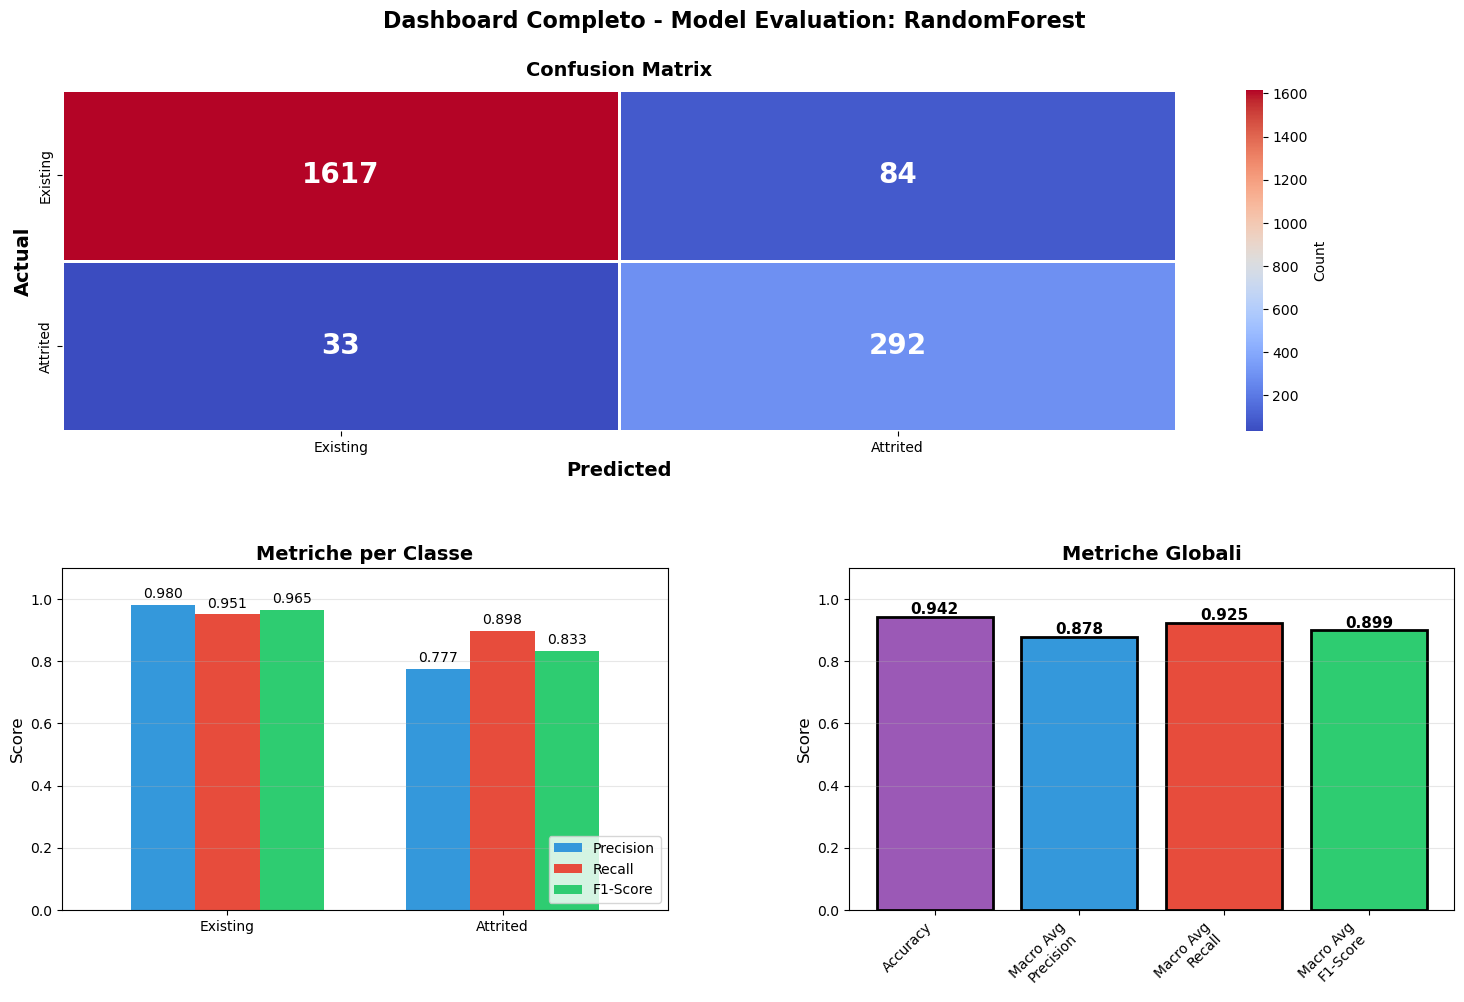

In [34]:
# ===========================
# OPZIONE 5: DASHBOARD COMPLETO CON TUTTE LE METRICHE
# ===========================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Calcola la confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Crea la figura con subplots_adjust invece di tight_layout
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.3, top=0.90, bottom=0.08, left=0.08, right=0.95)

# 1. Confusion Matrix principale
ax1 = fig.add_subplot(gs[0, :])
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', 
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'],
            linewidths=2, linecolor='white',
            cbar_kws={'label': 'Count'}, ax=ax1,
            annot_kws={'size': 20, 'weight': 'bold'})
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=10)  # Ridotto pad
ax1.set_ylabel('Actual', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted', fontsize=14, fontweight='bold')

# 2. Metriche per classe
ax2 = fig.add_subplot(gs[1, 0])
metrics_per_class = {
    'Existing': {
        'Precision': precision_score(y_test, y_pred, pos_label=0),
        'Recall': recall_score(y_test, y_pred, pos_label=0),
        'F1-Score': f1_score(y_test, y_pred, pos_label=0)
    },
    'Attrited': {
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'F1-Score': f1_score(y_test, y_pred, pos_label=1)
    }
}

df_metrics = pd.DataFrame(metrics_per_class).T
df_metrics.plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c', '#2ecc71'], 
                width=0.7, rot=0)
ax2.set_title('Metriche per Classe', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12)
ax2.set_ylim([0, 1.1])
ax2.legend(loc='lower right')
ax2.grid(axis='y', alpha=0.3)

# Aggiungi valori sopra le barre
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', padding=3)

# 3. Metriche globali
ax3 = fig.add_subplot(gs[1, 1])
overall_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Macro Avg\nPrecision': precision_score(y_test, y_pred, average='macro'),
    'Macro Avg\nRecall': recall_score(y_test, y_pred, average='macro'),
    'Macro Avg\nF1-Score': f1_score(y_test, y_pred, average='macro')
}

bars = ax3.bar(range(len(overall_metrics)), list(overall_metrics.values()), 
               color=['#9b59b6', '#3498db', '#e74c3c', '#2ecc71'], 
               edgecolor='black', linewidth=2)
ax3.set_xticks(range(len(overall_metrics)))
ax3.set_xticklabels(list(overall_metrics.keys()), rotation=45, ha='right')
ax3.set_title('Metriche Globali', fontsize=14, fontweight='bold')
ax3.set_ylabel('Score', fontsize=12)
ax3.set_ylim([0, 1.1])
ax3.grid(axis='y', alpha=0.3)

# Aggiungi valori sopra le barre
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', 
             fontweight='bold', fontsize=11)

# Titolo principale senza emoji (risolve il warning del font)
fig.suptitle('Dashboard Completo - Model Evaluation: RandomForest', 
             fontsize=16, fontweight='bold', y=0.98)  # Aggiunto y=0.98

plt.show()